# Task 3

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time

from tools.pcd_tools import downsample_voxel, pcd_from_path
from tools.plot_tools import plot_pcd, show_pcl
from tools.analysis_tools import calc_error
from tools.ICP import ICP, rigid_transformation, calculate_centroid

## Dataset tooling

In [33]:
class ICPLocalizer:
    def __init__(self, map_path: str, gt_path: str, frames_dir: str):
        """
        Initialize the ICP localizer with map and frames directory.
        
        Args:
            map_path (str): Path to the map.pcd file
            gt_path (str): Path to the ground truth file
            frames_dir (str): Directory containing frame PCDs
        """
        # Load map and ground truth
        self.map_path = map_path
        self.gt_path = gt_path
        self.frames_dir = frames_dir
        
        # Load ground truth data
        self.ground_truth = pd.read_csv(gt_path, skipinitialspace=True)
        
        # Load and preprocess map
        print("Loading and preprocessing map...")
        self.map_raw = pcd_from_path(map_path)
        
        # Downsample map for efficiency
        self.voxel_size = 0.25
        self.map_downsampled, _ = downsample_voxel(self.map_raw, self.voxel_size)
        
        # Create custom ICP instance
        # self.icp = ICP(max_dist=100, max_iterations=1000)
        self.icp = ICP(max_dist=100, max_iterations=1000)
        
        # Results storage
        self.estimated_poses = []
        self.position_errors = []
        self.yaw_errors = []
        self.computation_times = []
        self.reset_frames = []  # Track frames where reset occurred
        
        print(f"Map loaded with {len(self.map_downsampled)} points after downsampling")
    
    def transform_to_matrix(self, R: np.ndarray, t: np.ndarray) -> np.ndarray:
        """
        Convert rotation matrix and translation vector to 4x4 transformation matrix.
        
        Args:
            R (np.ndarray): 3x3 rotation matrix
            t (np.ndarray): 3x1 translation vector
            
        Returns:
            np.ndarray: 4x4 transformation matrix
        """
        T = np.eye(4)
        T[:3, :3] = R
        T[:3, 3] = t.flatten()  # Make sure translation is flat
        return T
    
    def matrix_to_transform(self, T: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Convert 4x4 transformation matrix to rotation matrix and translation vector.
        
        Args:
            T (np.ndarray): 4x4 transformation matrix
            
        Returns:
            Tuple[np.ndarray, np.ndarray]: Rotation matrix and translation vector
        """
        R = T[:3, :3]
        t = T[:3, 3].reshape(3, 1)  # Reshape to column vector
        return R, t
    
    def apply_transformation(self, points: np.ndarray, T: np.ndarray) -> np.ndarray:
        """
        Apply transformation matrix to points.
        
        Args:
            points (np.ndarray): Points to transform (Nx3)
            T (np.ndarray): 4x4 transformation matrix
            
        Returns:
            np.ndarray: Transformed points
        """
        # Extract rotation and translation
        R, t = self.matrix_to_transform(T)
        
        # Apply using the rigid_transformation function
        return rigid_transformation(points, R, t)
    
    def process_frame(self, frame_index: int, initial_pose: np.ndarray = None) -> Tuple[np.ndarray, np.ndarray, float, float]:
        """
        Process a single frame using ICP.
        
        Args:
            frame_index (int): Index of the frame to process
            initial_pose (np.ndarray, optional): Initial transformation matrix
            
        Returns:
            Tuple[np.ndarray, np.ndarray, float, float, float, np.ndarray]: 
                Estimated position, orientation, errors, computation time, transformation
        """
        # Load frame
        frame_path = os.path.join(self.frames_dir, f"frame_{frame_index}.pcd")
        if not os.path.exists(frame_path):
            raise FileNotFoundError(f"Frame {frame_path} not found")
        
        frame_raw = pcd_from_path(frame_path)
        
        # Downsample frame for efficiency
        frame_downsampled, _ = downsample_voxel(frame_raw, self.voxel_size)
        
        # Get ground truth for this frame
        gt_row = self.ground_truth.iloc[frame_index]
        gt_position = gt_row[['x', 'y', 'z']].to_numpy()
        gt_orientation = gt_row[['roll', 'pitch', 'yaw']].to_numpy()
        
        # Determine initial pose
        if initial_pose is None and frame_index == 0:
            # Use ground truth as initial pose
            initial_rotation = Rotation.from_euler('xyz', gt_orientation).as_matrix()
            initial_pose = np.eye(4)
            initial_pose[:3, :3] = initial_rotation
            initial_pose[:3, 3] = gt_position
        
        # Apply initial transformation to frame
        initial_R, initial_t = self.matrix_to_transform(initial_pose)
        transformed_frame = rigid_transformation(frame_downsampled, initial_R, initial_t)
        
        # Run ICP
        start_time = time.time()
        
        # Run custom ICP alignment (transformed_frame is already transformed by initial pose)
        R, t, R_list, t_list, _ = self.icp.align(transformed_frame, self.map_downsampled)
        
        end_time = time.time()
        computation_time = end_time - start_time
        
        # Final transformation = initial_pose * [R|t]
        # Since transformed_frame is already transformed by initial_pose, we can directly use R and t
        final_transformation = self.transform_to_matrix(R, t)
        
        # Extract position and orientation from transformation matrix
        estimated_position = final_transformation[:3, 3]
        estimated_rotation_matrix = final_transformation[:3, :3]
        estimated_orientation = Rotation.from_matrix(estimated_rotation_matrix).as_euler('xyz')
        
        # Calculate errors
        position_error, yaw_error = calc_error(
            gt_position, gt_orientation, 
            estimated_position, estimated_orientation
        )
        
        return estimated_position, estimated_orientation, position_error, yaw_error, computation_time, final_transformation
    
    def run_localization(self, num_frames: int = None):
        """
        Run ICP localization on all frames.
        
        Args:
            num_frames (int, optional): Number of frames to process. If None, process all frames.
        """
        try:
            # Try to import tqdm.notebook for Jupyter integration
            from tqdm.notebook import tqdm as progress_bar
        except ImportError:
            # Fallback to standard tqdm
            from tqdm import tqdm as progress_bar
        
        if num_frames is None:
            # Count frames in directory
            frame_files = [f for f in os.listdir(self.frames_dir) if f.startswith("frame_") and f.endswith(".pcd")]
            num_frames = len(frame_files)
        
        print(f"Running ICP localization on {num_frames} frames...")
        
        # Initialize with identity transformation
        previous_pose = None
        
        # Setup progress bar
        bar = progress_bar(range(num_frames))
        
        for frame_idx in bar:
            # Process frame
            estimated_position, estimated_orientation, position_error, yaw_error, computation_time, transformation_matrix = self.process_frame(
                frame_idx, initial_pose=previous_pose
            )
            
            # Store results
            self.estimated_poses.append(transformation_matrix)
            self.position_errors.append(position_error)
            self.yaw_errors.append(yaw_error)
            self.computation_times.append(computation_time)
            
            # Apply smoothing for non-reset frames
            if frame_idx > 0 and frame_idx not in self.reset_frames:
                # Get current position and previous position
                curr_pos = transformation_matrix[:3, 3]
                prev_pos = self.estimated_poses[-2][:3, 3]
                
                # Calculate distance between consecutive positions
                dist = np.linalg.norm(curr_pos - prev_pos)
                
                # If distance is too large, apply smoothing
                if dist > 0.5:  # meters
                    # Apply exponential smoothing
                    alpha = 0.3  # Smoothing factor (0 < alpha < 1)
                    smoothed_pos = alpha * curr_pos + (1 - alpha) * prev_pos
                    
                    # Update position in transformation matrix
                    smoothed_transform = transformation_matrix.copy()
                    smoothed_transform[:3, 3] = smoothed_pos
                    
                    # Update stored pose
                    self.estimated_poses[-1] = smoothed_transform
                    transformation_matrix = smoothed_transform
            
            # Update previous pose for next iteration
            previous_pose = transformation_matrix
            
            # Update progress bar
            bar.set_postfix(
                position_error=f"{position_error:.3f}m", 
                yaw_error=f"{yaw_error:.3f}rad", 
                time=f"{computation_time:.3f}s"
            )
        
        print("Localization completed.")
    
    def plot_results(self):
        """
        Plot localization results and errors.
        """
        # Create figure
        fig, axs = plt.subplots(3, 1, figsize=(12, 15))
        
        # Plot position errors
        axs[0].plot(self.position_errors)
        axs[0].set_title('Position Error')
        axs[0].set_xlabel('Frame')
        axs[0].set_ylabel('Error (m)')
        axs[0].grid(True)
        
        # Highlight reset frames
        for reset_frame in self.reset_frames:
            if reset_frame < len(self.position_errors):
                axs[0].axvline(x=reset_frame, color='r', linestyle='--', alpha=0.5)
        
        # Add horizontal line for error threshold
        axs[0].axhline(y=1.2, color='g', linestyle='--', label='Required threshold (1.2m)')
        axs[0].legend()
        
        # Plot yaw errors
        axs[1].plot(self.yaw_errors)
        axs[1].set_title('Yaw Error')
        axs[1].set_xlabel('Frame')
        axs[1].set_ylabel('Error (rad)')
        axs[1].grid(True)
        
        # Plot computation times
        axs[2].plot(self.computation_times)
        axs[2].set_title('Computation Time')
        axs[2].set_xlabel('Frame')
        axs[2].set_ylabel('Time (s)')
        axs[2].grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print("Statistics:")
        print(f"Average position error: {np.mean(self.position_errors):.3f}m")
        print(f"Maximum position error: {np.max(self.position_errors):.3f}m")
        print(f"Average yaw error: {np.mean(self.yaw_errors):.3f}rad")
        print(f"Average computation time: {np.mean(self.computation_times):.3f}s")
        print(f"Number of resets performed: {len(self.reset_frames)}")
        
        # Check if result meets requirements
        if np.max(self.position_errors) <= 1.2:
            print("\n✅ Success! Maximum error is within the 1.2m requirement.")
        else:
            print(f"\n❌ Maximum error ({np.max(self.position_errors):.3f}m) exceeds the 1.2m requirement.")
            
            # Calculate percentage of frames with error below threshold
            frames_below_threshold = sum(1 for err in self.position_errors if err <= 1.2)
            percentage = frames_below_threshold / len(self.position_errors) * 100
            print(f"However, {percentage:.1f}% of frames have error below the 1.2m threshold.")
    
    def visualize_trajectory(self):
        """
        Visualize the ground truth and estimated trajectories.
        """
        # Extract ground truth trajectory
        gt_positions = self.ground_truth[['x', 'y']].to_numpy()
        
        # Extract estimated trajectory
        est_positions = np.array([pose[:3, 3][:2] for pose in self.estimated_poses])
        
        # Create figure
        plt.figure(figsize=(12, 10))
        
        # Plot trajectories
        plt.plot(gt_positions[:, 0], gt_positions[:, 1], 'b-', label='Ground Truth')
        plt.plot(est_positions[:, 0], est_positions[:, 1], 'r-', label='ICP Estimate')
        
        # Mark reset points
        for reset_frame in self.reset_frames:
            if reset_frame < len(est_positions):
                plt.plot(est_positions[reset_frame, 0], est_positions[reset_frame, 1], 'go', markersize=5)
        
        # Plot map points (subsample for better visualization)
        subsample_factor = 30  # Adjust based on map density
        plt.scatter(self.map_downsampled[::subsample_factor, 0], self.map_downsampled[::subsample_factor, 1], 
                   c='gray', s=0.1, alpha=0.3, label='Map (subsampled)')
        
        plt.title('Vehicle Trajectory')
        plt.xlabel('X (m)')
        plt.ylabel('Y (m)')
        plt.legend()
        plt.grid(True)
        plt.axis('equal')
        plt.show()
        
    def analyze_segment_errors(self):
        """
        Analyze errors by segments between resets.
        """
        reset_frames = [0] + self.reset_frames + [len(self.position_errors)]
        reset_frames = sorted(list(set(reset_frames)))  # Ensure unique and sorted
        
        print("\nSegment Analysis:")
        print("-" * 80)
        print(f"{'Segment':^10}{'Start Frame':^15}{'End Frame':^15}{'Avg Error (m)':^15}{'Max Error (m)':^15}")
        print("-" * 80)
        
        for i in range(len(reset_frames) - 1):
            start_idx = reset_frames[i]
            end_idx = min(reset_frames[i+1], len(self.position_errors))
            
            # Position errors in this segment
            segment_errors = self.position_errors[start_idx:end_idx]
            
            print(f"{i:^10}{start_idx:^15}{end_idx:^15}{np.mean(segment_errors):^15.3f}{np.max(segment_errors):^15.3f}")
        
        print("-" * 80)

# Function to run the localization pipeline
def run_icp_localization(map_path, gt_path, frames_dir, num_frames=None):
    """
    Run the full ICP localization pipeline.
    
    Args:
        map_path (str): Path to map PCD file
        gt_path (str): Path to ground truth CSV file
        frames_dir (str): Directory containing frame PCD files
        num_frames (int, optional): Number of frames to process. Default is None (all frames).
    """
    # Create localizer instance
    localizer = ICPLocalizer(map_path, gt_path, frames_dir)
    
    # Run localization
    localizer.run_localization(num_frames)
    
    # Visualize results
    localizer.plot_results()
    localizer.visualize_trajectory()
    localizer.analyze_segment_errors()
    
    return localizer

Loading and preprocessing map...
Map loaded with 106740 points after downsampling
Running ICP localization on 100 frames...


  0%|          | 0/100 [00:00<?, ?it/s]

Localization completed.


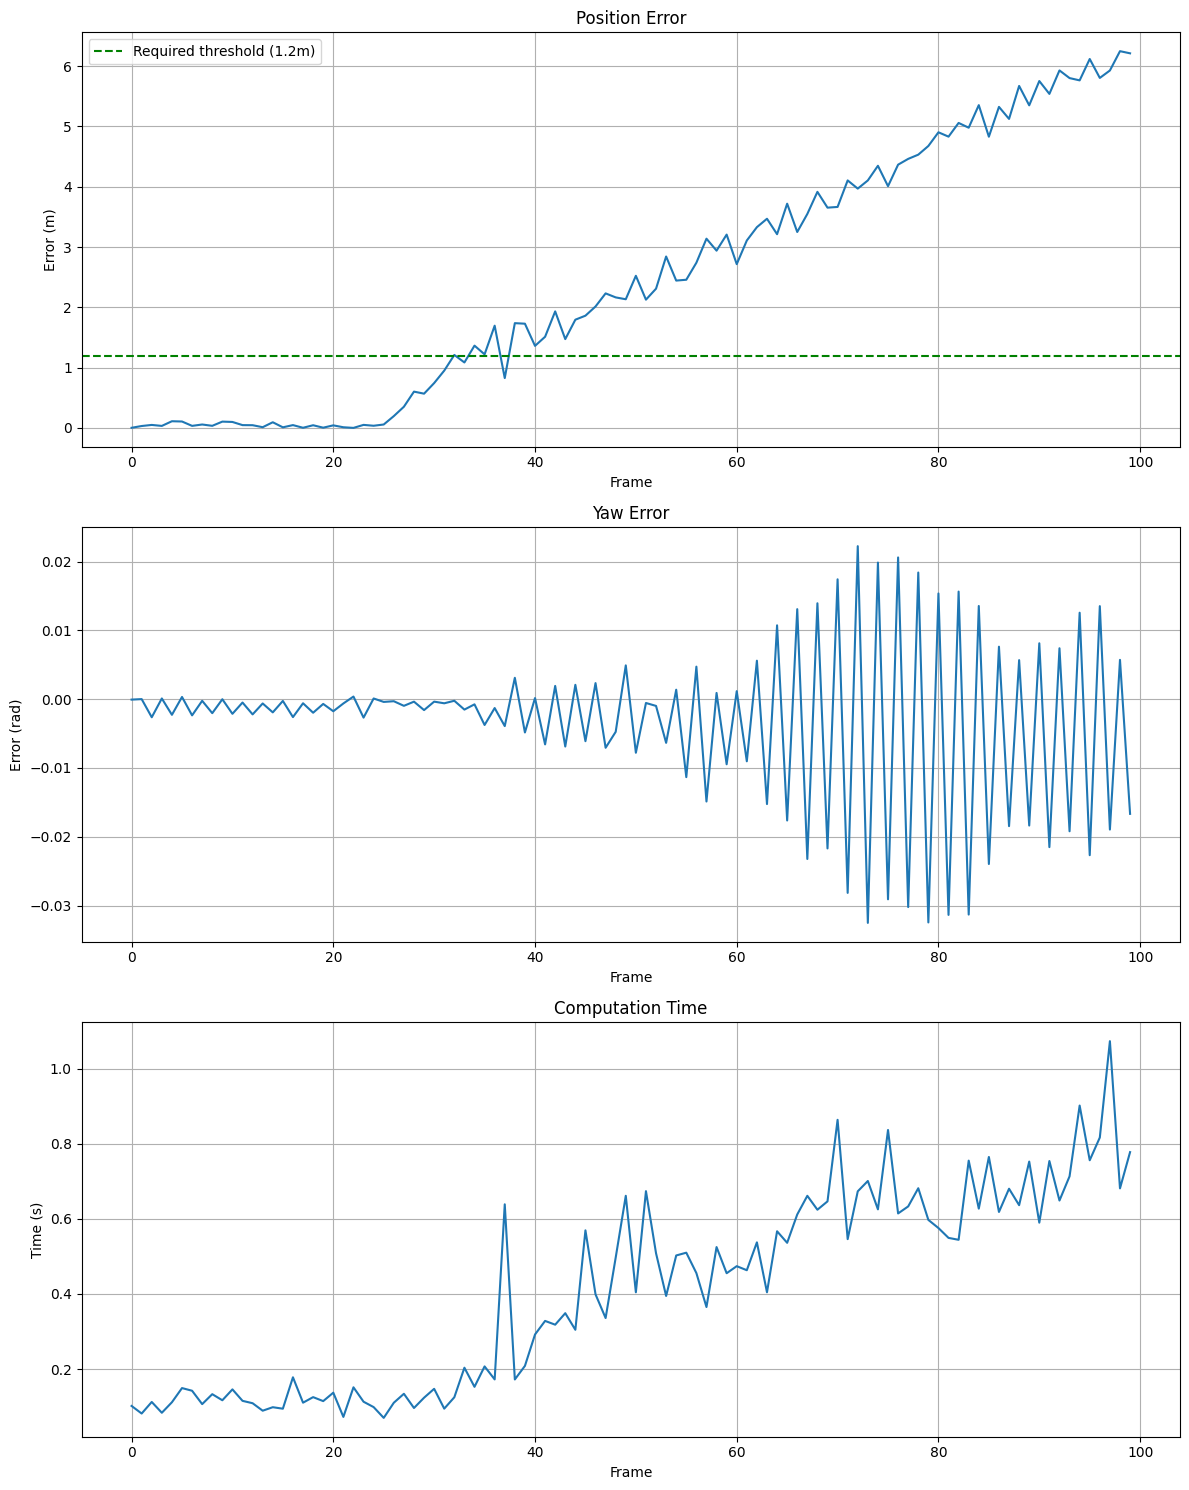

Statistics:
Average position error: 2.473m
Maximum position error: 6.246m
Average yaw error: -0.003rad
Average computation time: 0.409s
Number of resets performed: 0

❌ Maximum error (6.246m) exceeds the 1.2m requirement.
However, 34.0% of frames have error below the 1.2m threshold.


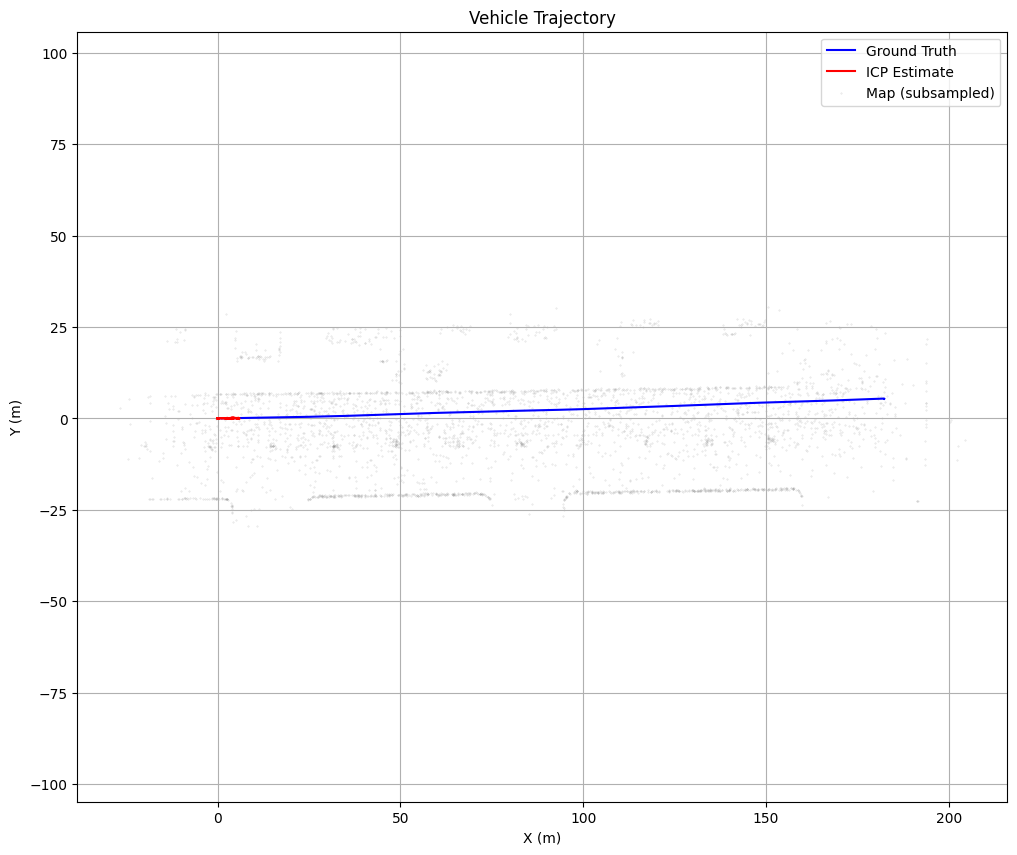

In [34]:
# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

# Create the ICP localizer
localizer = ICPLocalizer(MAP_PATH, GT_PATH, FRAMES_DIR)

# Run localization (use a smaller number for testing, like 100 frames)
localizer.run_localization(num_frames=100)

# Plot and visualize results
localizer.plot_results()
localizer.visualize_trajectory()